# US VAR from FRED

This notebook downloads US macro series from FRED and estimates a VAR with:
- inflation
- gdp growth
- interest rate

Cholesky ordering is set as: `inflation -> gdp_growth -> interest_rate`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas_datareader import data as web
from statsmodels.tsa.api import VAR

In [5]:
# 1) Download US macro data from FRED
start_date = "1985-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

cpi_m = web.DataReader("CPIAUCSL", "fred", start_date, end_date)   # CPI (monthly)
gdp_q = web.DataReader("GDPC1", "fred", start_date, end_date)      # Real GDP (quarterly)
ffr_m = web.DataReader("FEDFUNDS", "fred", start_date, end_date)   # Fed Funds Rate (monthly)

# 2) Convert everything to quarterly PeriodIndex to guarantee alignment
cpi_q = cpi_m.resample("QE").mean().to_period("Q")
ffr_q = ffr_m.resample("QE").mean().to_period("Q")
gdp_q = gdp_q.to_period("Q")

# 3) Build transformed VAR dataset
# inflation and GDP growth as annualized quarterly log-differences
# interest rate in levels
us = pd.concat([cpi_q, gdp_q, ffr_q], axis=1)
us.columns = ["cpi", "gdp", "interest_rate"]
us["inflation"] = 400 * np.log(us["cpi"]).diff()
us["gdp_growth"] = 400 * np.log(us["gdp"]).diff()

var_data = us[["inflation", "gdp_growth", "interest_rate"]].dropna()
print(f"VAR sample size: {len(var_data)}")
var_data.head()

VAR sample size: 163


,inflation,gdp_growth,interest_rate
DATE,,,
1985Q2,3.622195,3.506480,7.923333
1985Q3,2.479091,6.062904,7.900000
1985Q4,4.057204,2.962797,8.103333
1986Q1,2.074124,3.717661,7.826667
1986Q2,-1.951818,1.797142,6.920000


In [6]:
# 4) Estimate VAR with safe lag selection for short samples
model = VAR(var_data)

requested_maxlags = 8
working_maxlags = None
lag_select = None

# Try from requested_maxlags downward until select_order is feasible.
for ml in range(requested_maxlags, 0, -1):
    try:
        lag_select = model.select_order(maxlags=ml)
        working_maxlags = ml
        break
    except ValueError:
        continue

if lag_select is not None:
    p = lag_select.selected_orders.get("aic", 1)
    if p is None:
        p = 1
    p = max(1, min(int(p), working_maxlags))
else:
    # If IC selection is still infeasible, use a conservative fallback.
    p = 1
    working_maxlags = 1

res = model.fit(p)
print(f"Requested maxlags={requested_maxlags}, feasible maxlags={working_maxlags}")
print(f"Selected lag (AIC/fallback): p={p}")
print("Cholesky order:", var_data.columns.tolist())
print(res.summary())

Requested maxlags=8, feasible maxlags=8
Selected lag (AIC/fallback): p=2
Cholesky order: ['inflation', 'gdp_growth', 'interest_rate']
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 09, Mar, 2026
Time:                     20:27:29
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    2.17464
Nobs:                     161.000    HQIC:                   1.93591
Log likelihood:          -807.051    FPE:                    5.88778
AIC:                      1.77271    Det(Omega_mle):         5.18205
--------------------------------------------------------------------
Results for equation inflation
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                    1.362915         0.333204            4.090           

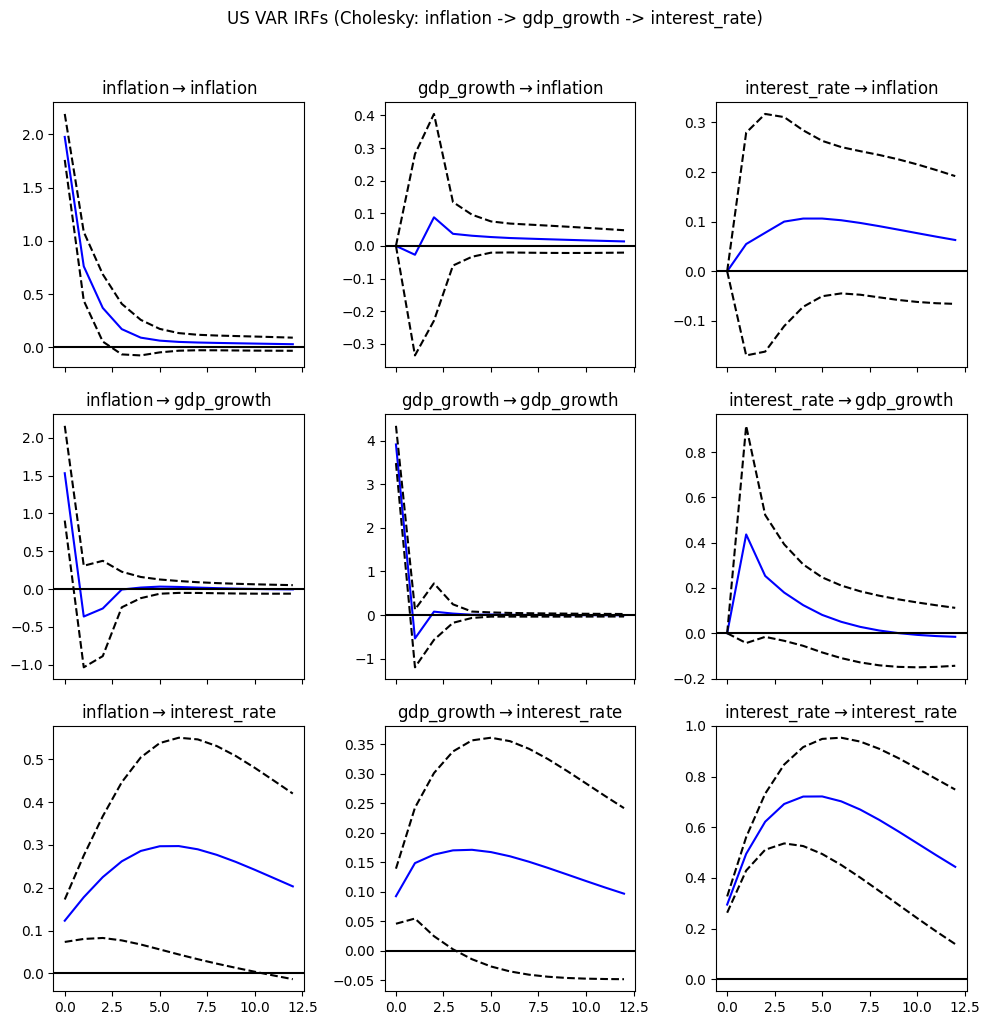

In [8]:
# 5) Orthogonalized IRFs (Cholesky decomposition)
# Because var_data columns are ordered as inflation, gdp_growth, interest_rate,
# inflation is the top variable in the Cholesky ordering.
irf = res.irf(12)
irf.plot(orth=True)
plt.suptitle("US VAR IRFs (Cholesky: inflation -> gdp_growth -> interest_rate)", y=1.02)
plt.tight_layout()
plt.show()